# 18 &middot; Rotation&ndash;Strain Coordinates: Rescuing a Linear Mode

A **linear mode** deforms a shape as $x(a)=X+a\,\phi$: one precomputed displacement field $\phi$, one
scalar $a$. But it moves every vertex along a fixed straight line, so where a bending beam should *rotate*
its tip along an arc, the linear mode shoots the tip off along the tangent and spuriously **stretches**
the elements. **Rotation&ndash;strain (RS) coordinates** repair this after the fact: split each element's
displacement gradient $\nabla u$ into its antisymmetric part (a rotation generator) and its symmetric part
(the strain), exponentiate the first into a true rotation, keep the second, and refit one displacement
field. We pull three modes out of a pinned beam, actuate a bending mode far past small amplitudes,
correct it with RS, and show that RS removes the fake stretch of bending modes while keeping the genuine
stretch of an axial mode.

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import igl
import simkit
import utils

NOTEBOOK = "018_rotation_strain_coordinates"                      # this file's name
RESULTS_DIR = simkit.filesystem.notebook_results_path(NOTEBOOK)    # results/018_rotation_strain_coordinates/
MEDIA_DIR = "media"                                                # tracked copies for the website
# beam
NX, NY = 48, 7                  # grid resolution (vertices)
WIDTH, HEIGHT = 4.0, 0.6        # beam size
# modes
N_MODES = 3                     # linear modes to compute
MODE_SHOW_AMP = 1.0             # amplitude at which the modes are drawn
# actuation
ACT_MODE = 0                    # mode that is actuated (0 = fundamental bend)
A_MAX = 3.0                     # peak actuation amplitude (world units of peak displacement)
N_FRAMES = 61                   # frames of the one-period sine actuation
FPS = 20                        # video frame rate
# RS fit
K_PIN = 1e8                     # stiffness of the zero-displacement pin spring (simkit's RS value)
FD_STEP = 1e-6                  # central-difference step of the gradient check
NEWTON_ITERS = 5                # max Newton iterations of the fit (it is quadratic: one step solves it)
NEWTON_TOL = 1e-10              # stop when the Newton step is shorter than this
# amplitude sweep
SWEEP_AMPS = np.linspace(0.0, A_MAX, 16)   # amplitudes of the distortion-vs-amplitude chart
# plot cosmetics
AREA_NORM = TwoSlopeNorm(vmin=0.0, vcenter=1.0, vmax=2.0)   # area-ratio colors: white = 1 (rigid)
LIN_C, RS_C, REST_C = "#d62728", "#2ca02c", "#bdbdbd"     # raw linear, RS-corrected, rest ghost

## A cantilever beam, pinned on the left

An `igl.triangulated_grid`, centered and scaled to a 4 &times; 0.6 beam, with its whole left edge clamped
(blue squares). The free right end swings through the largest angle, so it is where the linear
approximation breaks first.

beam: 336 vertices, 564 triangles, 672 DOFs; pinned: 7 vertices


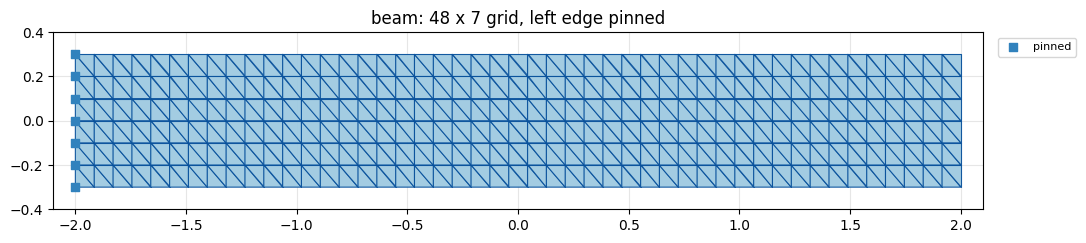

In [2]:
V, T = igl.triangulated_grid(NX, NY)                 # unit square, NX x NY vertices
X = (V - 0.5) * np.array([WIDTH, HEIGHT])            # centered WIDTH x HEIGHT rectangle
n, dim = X.shape
pin = np.where(X[:, 0] <= X[:, 0].min() + 1e-6)[0]   # clamp the whole left edge
print(f"beam: {n} vertices, {len(T)} triangles, {n * dim} DOFs; pinned: {len(pin)} vertices")

fig, ax = plt.subplots(figsize=(12, 2.3))
utils.plot_mesh(ax, X, T, pins=pin, title=f"beam: {NX} x {NY} grid, left edge pinned")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8)   # keep the legend off the mesh
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "mesh.png"),
                              copy_to=os.path.join(MEDIA_DIR, "018_mesh.png"))
plt.show()

## The first three linear modes

`simkit.linear_modal_analysis` solves $K\phi=\lambda M\phi$ for the linear-elastic stiffness $K$ (unit Lam&eacute;
parameters) and the lumped mass $M$, with the pinned DOFs removed, and returns the lowest modes
($\lambda$ is the squared frequency). We rescale each mode so its largest displacement component is 1, so
$a$ reads as roughly how far the most-displaced vertex moves. The figure draws each mode at $a=1$ over the
gray rest beam, colored by $|\phi|$: modes 1 and 2 are the first two bends, mode 3 is axial.

eigenvalues (squared frequency): [0.0041 0.132  0.4134]


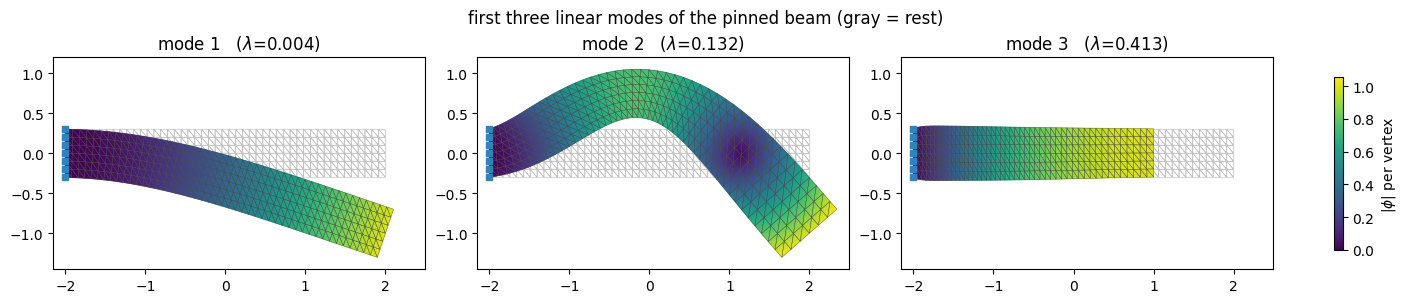

In [3]:
eigvals, B = simkit.linear_modal_analysis(X, T, N_MODES, bI=pin)
modes = [B[:, i].reshape(n, dim) for i in range(N_MODES)]
modes = [m / np.abs(m).max() for m in modes]                 # unit peak displacement
print("eigenvalues (squared frequency):", np.round(eigvals, 4))

lims = utils.auto_limits([X] + [X + MODE_SHOW_AMP * m for m in modes], pad=0.15)
phi_max = max(np.linalg.norm(m, axis=1).max() for m in modes)
fig, axes = plt.subplots(1, N_MODES, figsize=(14, 2.9), layout="constrained")
for i, (ax, m) in enumerate(zip(axes, modes)):
    utils.PolyMeshArtist(ax, X, T, facecolor="none", edgecolor=REST_C, lw=0.5, zorder=0.5)
    field = utils.plot_scalar_field(ax, X + MODE_SHOW_AMP * m, T, np.linalg.norm(m, axis=1),
                                    vmin=0.0, vmax=phi_max, lims=lims,
                                    colorbar=False, title=f"mode {i+1}   ($\\lambda$={eigvals[i]:.3f})")
    ax.scatter(X[pin, 0], X[pin, 1], s=22, color=utils.PIN_C, marker="s", zorder=5)
fig.colorbar(field, ax=axes, shrink=0.8, label="$|\\phi|$ per vertex")
fig.suptitle("first three linear modes of the pinned beam (gray = rest)")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "modes.png"),
                              copy_to=os.path.join(MEDIA_DIR, "018_modes.png"))
plt.show()

## Rotation or strain? Split each mode's gradient

The deformation Jacobian $J$ (`simkit.deformation_jacobian`) turns vertex displacements into each
element's displacement gradient, which splits orthogonally into a rotation generator and a strain,
$$
\nabla u=\underbrace{\tfrac12(\nabla u-\nabla u^\top)}_{W=\left[\begin{smallmatrix}0&-w\\ w&0\end{smallmatrix}\right]}
+\underbrace{\tfrac12(\nabla u+\nabla u^\top)}_{\mathrm{sym}(\nabla u)},\qquad
\|\nabla u\|_F^2=\|W\|_F^2+\|\mathrm{sym}(\nabla u)\|_F^2 .
$$
Below, per element and per unit amplitude, the rotation size $\|W\|_F=\sqrt2\,|w|$ next to the strain size
$\|\mathrm{sym}(\nabla\phi)\|_F$, on one color scale per mode (row). The printed share is the
area-weighted fraction of $\|\nabla\phi\|_F^2$ that is rotation.

mode 1: rotation share of |grad phi|^2 =  99.7%
mode 2: rotation share of |grad phi|^2 =  98.4%
mode 3: rotation share of |grad phi|^2 =   0.6%


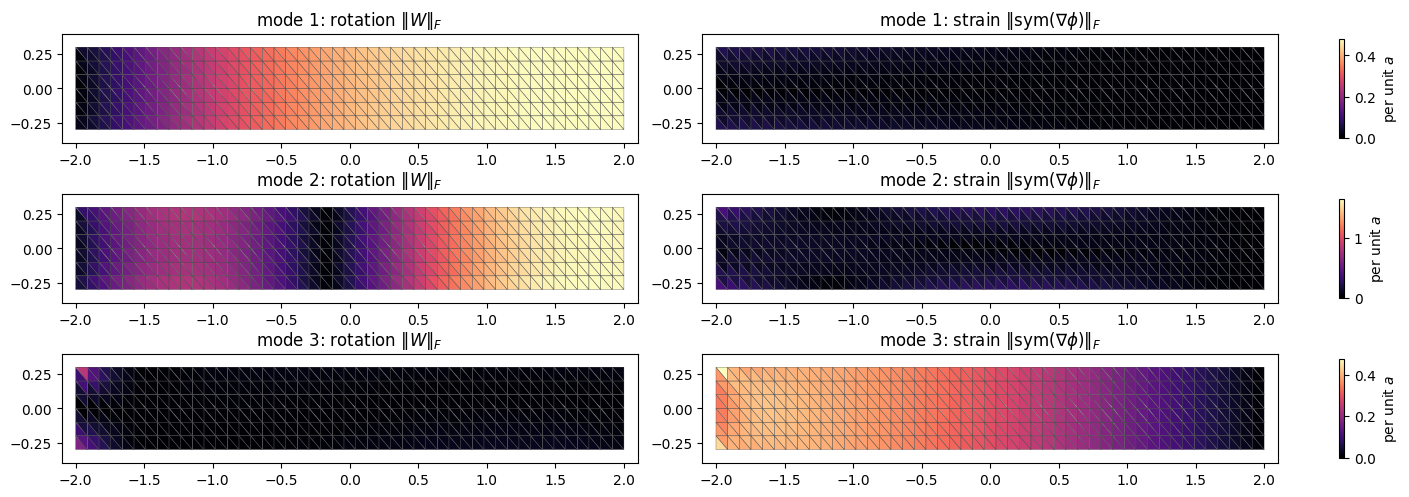

In [4]:
J = simkit.deformation_jacobian(X, T)               # (n_elements * dim*dim, n*dim)
vol = simkit.volume(X, T)                           # rest element areas, (n_elements, 1)
fig, axes = plt.subplots(N_MODES, 2, figsize=(14, 4.8), layout="constrained")
for i, m in enumerate(modes):
    grad_u = (J @ m.reshape(-1, 1)).reshape(-1, dim, dim)      # per-element displacement gradient
    W = 0.5 * (grad_u - grad_u.transpose(0, 2, 1))              # rotation generator (skew part)
    sym = 0.5 * (grad_u + grad_u.transpose(0, 2, 1))            # strain (symmetric part)
    rot_size = np.linalg.norm(W, axis=(1, 2))
    strain_size = np.linalg.norm(sym, axis=(1, 2))
    rot_sq = np.sum(vol.ravel() * rot_size**2)
    strain_sq = np.sum(vol.ravel() * strain_size**2)
    print(f"mode {i+1}: rotation share of |grad phi|^2 = {rot_sq / (rot_sq + strain_sq):6.1%}")

    top = max(rot_size.max(), strain_size.max())             # one color scale per mode
    field = utils.plot_scalar_field(axes[i, 0], X, T, rot_size, cmap="magma", vmin=0.0, vmax=top,
                                    colorbar=False, title=f"mode {i+1}: rotation $\\|W\\|_F$")
    field = utils.plot_scalar_field(axes[i, 1], X, T, strain_size, cmap="magma", vmin=0.0, vmax=top,
                                    colorbar=False, title=f"mode {i+1}: strain $\\|\\mathrm{{sym}}(\\nabla\\phi)\\|_F$")
    fig.colorbar(field, ax=axes[i, :], shrink=0.9, label="per unit $a$")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "mode_split.png"),
                              copy_to=os.path.join(MEDIA_DIR, "018_mode_split.png"))
plt.show()

In both bends the rotation dwarfs the strain everywhere (mode 1 turns more and more toward the tip; mode 2
passes through zero rotation at its crest), while the axial mode is almost pure strain. That is exactly
the distinction RS coordinates key off.

## Actuate the first mode, sinusoidally

Drive the fundamental bend with one sine period, $a(t)=A_{\max}\sin(2\pi t)$ for $t\in[0,1]$ and
$A_{\max}=3$, far past small amplitudes. Each element is colored by its **area ratio**
$r_e=\det F_e$ (deformed over rest area, with $F=I+\nabla u$ from `simkit.deformation_gradient`). A rigid
rotation keeps $r_e=1$ (white), so a faithful bend would stay nearly white. Instead the elements toward
the tip flush **red** whenever it swings out: the straight-line mode inflates them. The right panel traces
the worst element; a still of a peak-swing frame goes to `media/018_linear_artifacts.png`.

In [5]:
tt = np.linspace(0.0, 1.0, N_FRAMES)
a_t = A_MAX * np.sin(2.0 * np.pi * tt)               # one full sine period
mode = modes[ACT_MODE]
states_lin = [X + a * mode for a in a_t]
ratio_lin = [np.linalg.det(simkit.deformation_gradient(X, T, U)) for U in states_lin]
peak_lin = np.array([r.max() for r in ratio_lin])
peak_frame = int(np.argmax(peak_lin))
anim_lims = utils.auto_limits(states_lin, pad=0.25)            # shared by both animations
print(f"raw linear mode at A_MAX={A_MAX}: peak area ratio {peak_lin.max():.2f}x, "
      f"smallest area ratio {min(r.min() for r in ratio_lin):+.2f} (negative would mean inverted)")

fig, anim = utils.animate_fields_trace(
    [{"states": states_lin, "fields": ratio_lin,
      "title": "linear actuation $x=X+a\\,\\phi$ (color = area ratio)"}],
    T, tt, {"raw linear mode": peak_lin}, cmap="RdBu_r", norm=AREA_NORM,
    cbar_label="area ratio $\\det F$ (1 = rigid)", pin_pts=X[pin], colors={"raw linear mode": LIN_C},
    xlabel="actuation phase $t$", ylabel="peak area ratio (max over elements)",
    title="straight-line actuation inflates area", ref_line=1.0, pose=peak_frame, fps=FPS,
    lims=anim_lims, figsize=(9.5, 4.6))
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "linear_artifacts.png"),
                              copy_to=os.path.join(MEDIA_DIR, "018_linear_artifacts.png"))
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "linear_artifacts.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "018_linear_artifacts.mp4"))
plt.close(fig)
utils.embed_video(video)

raw linear mode at A_MAX=3.0: peak area ratio 2.03x, smallest area ratio +0.82 (negative would mean inverted)


The smallest ratio stays positive, so nothing inverts at this amplitude: the artifact is pure inflation,
about 2&times; at the worst element, and it vanishes only as the beam passes back through rest.

## Why the linear mode inflates area, and the RS target

In 2D the area ratio splits exactly as $\det(I+\nabla u)=\det S+w^2$, with $S=I+\mathrm{sym}(\nabla u)$
the genuine stretch: the first-order rotation $I+W$ has $\det(I+W)=1+w^2$, so the linearized turn
itself inflates area by $w^2$. RS coordinates replace it with the exact rotation $R=\exp(W)$ by the angle
$w$ (Rodrigues' formula in 3D), which has $\det R=1$, and set each element's Jacobian target to
$Y=RS-I$: rotation upgraded, stretch untouched, so $\det(RS)=\det S$. The cell builds $Y$ at the peak
amplitude $a=A_{\max}$ and checks the identity.

In [6]:
u_peak = A_MAX * mode                                           # raw displacement at the peak swing
grad_u = (J @ u_peak.reshape(-1, 1)).reshape(-1, dim, dim)
W = 0.5 * (grad_u - grad_u.transpose(0, 2, 1))                   # rotation generator
S = np.eye(dim) + 0.5 * (grad_u + grad_u.transpose(0, 2, 1))     # genuine stretch
w = W[:, 1, 0]                                                   # rotation angle per element
R = np.stack([np.cos(w), -np.sin(w), np.sin(w), np.cos(w)], axis=1).reshape(-1, dim, dim)   # exp(W)
Y = R @ S - np.eye(dim)                                          # RS Jacobian target
det_raw = np.linalg.det(np.eye(dim) + grad_u)
e_worst = int(np.argmax(det_raw))
print(f"max |det(I + grad u) - (det S + w^2)| = {np.abs(det_raw - (np.linalg.det(S) + w**2)).max():.1e}")
print(f"worst raw element: det(I + grad u) = {det_raw[e_worst]:.2f} = det S {np.linalg.det(S)[e_worst]:.2f}"
      f" + w^2 {w[e_worst]**2:.2f}   (w = {w[e_worst]:+.2f} rad)")
print(f"max det R = {np.linalg.det(R).max():.3f}, so the RS target keeps det(R S) = det S")

max |det(I + grad u) - (det S + w^2)| = 8.9e-16
worst raw element: det(I + grad u) = 2.03 = det S 1.00 + w^2 1.03   (w = -1.02 rad)
max det R = 1.000, so the RS target keeps det(R S) = det S


## The RS fit as a system

A field of per-element targets $Y$ is generally not the gradient of any displacement, so RS solves a
least-squares fit, with the clamped vertices held at zero displacement by a stiff
`simkit.dirichlet_penalty` spring. `rs_fit_system` returns the energy, gradient and Hessian of
$$
E(u)=\underbrace{\tfrac12\sum_e \mathrm{vol}_e\,\big\|(Ju)_e-Y_e\big\|_F^2}_{\text{fit}}
+\underbrace{\tfrac{K}{2}\,\|u_{\text{pin}}\|^2}_{\text{pin}} ,
$$
a quadratic, so one Newton step solves it exactly. `simkit.rotation_strain_coordinates` does the same
solve with a prefactored Hessian (`RSPrecompute`).

In [7]:
def rs_fit_system(X, T, Y, pin_idx):
    """Least-squares fit of a displacement u whose Jacobian matches the targets Y, plus a soft zero pin."""
    n, dim = X.shape
    J = simkit.deformation_jacobian(X, T)
    vol = simkit.volume(X, T)
    Vol = sp.sparse.kron(sp.sparse.diags(vol.ravel()), sp.sparse.eye(dim * dim))   # element area per entry
    y = Y.reshape(-1, 1)
    Q_pin, b_pin = simkit.dirichlet_penalty(pin_idx, np.zeros((len(pin_idx), dim)), n, K_PIN)

    def energy_func(u):
        r = J @ u - y
        E_fit = 0.5 * np.sum(r * (Vol @ r))
        E_pin = simkit.energies.quadratic_energy(u, Q_pin, b_pin)
        E_total = E_fit + E_pin
        return E_total

    def gradient_func(u):
        g_fit = J.T @ (Vol @ (J @ u - y))
        g_pin = simkit.energies.quadratic_gradient(u, Q_pin, b_pin)
        g_total = g_fit + g_pin
        return g_total

    def hessian_func(u):
        H_fit = J.T @ Vol @ J
        H_pin = simkit.energies.quadratic_hessian(Q_pin)
        H_total = H_fit + H_pin
        return H_total

    return energy_func, gradient_func, hessian_func

Check `gradient_func` against central differences (`simkit.gradient_cfd`) at the raw displacement, solve
from $u=0$ with `simkit.solvers.newton_solver`, and compare with `simkit.rotation_strain_coordinates`.
The first Newton step should solve the quadratic (the second is already at round-off), and the two
answers should agree to round-off.

In [8]:
energy_func, gradient_func, hessian_func = rs_fit_system(X, T, Y, pin)
x_test = u_peak.reshape(-1, 1)
g = gradient_func(x_test)
g_fd = simkit.gradient_cfd(lambda z: np.array(energy_func(z.reshape(-1, 1))), x_test.ravel(), FD_STEP)
print(f"gradient check: |g_fd - g| / |g| = {np.linalg.norm(g_fd.reshape(-1, 1) - g) / np.linalg.norm(g):.1e}")

u0 = np.zeros((n * dim, 1))
u_fit, info = simkit.solvers.newton_solver(u0, energy_func, gradient_func, hessian_func, max_iter=NEWTON_ITERS,
                                           tolerance=NEWTON_TOL, do_line_search=False, return_info=True)
step_norms = ", ".join(f"{np.linalg.norm(dx):.1e}" for dx in info["dx"])
print(f"Newton step lengths: {step_norms};  |g| {np.linalg.norm(gradient_func(u0)):.2e} -> "
      f"{np.linalg.norm(gradient_func(u_fit)):.1e};  E {energy_func(u0):.3f} -> {energy_func(u_fit):.2e}")

u_rs, _ = simkit.rotation_strain_coordinates(X, T, u_peak.reshape(-1), pinned=pin)
print(f"max |u_newton - u_simkit| = {np.abs(u_fit.reshape(n, dim) - u_rs).max():.1e}"
      f"   (max |u_rs| = {np.abs(u_rs).max():.2f})")

gradient check: |g_fd - g| / |g| = 1.1e-09
Newton step lengths: 2.7e+01, 1.2e-12;  |g| 6.78e-01 -> 6.1e-15;  E 1.433 -> 2.12e-06
max |u_newton - u_simkit| = 9.7e-14   (max |u_rs| = 2.77)


Area ratio at the peak swing: the raw mode (left), the RS target $\det S$ drawn on the fitted RS shape
(middle), and what the fitted shape actually achieves (right). The fit reproduces the target almost
exactly, and both are far whiter than the raw mode; the remaining color is genuine bending strain.

peak area ratio: raw 2.03, RS target 1.14, RS fit 1.14;  max |fit - target| = 0.004


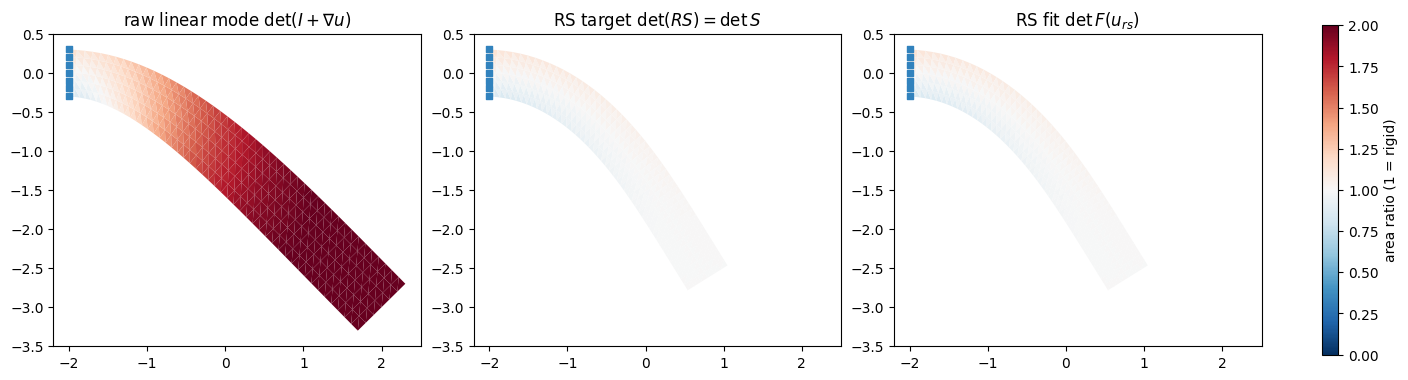

In [9]:
U_rs = X + u_fit.reshape(n, dim)                     # the notebook's own Newton solution
ratio_fit = np.linalg.det(simkit.deformation_gradient(X, T, U_rs))
print(f"peak area ratio: raw {det_raw.max():.2f}, RS target {np.linalg.det(S).max():.2f}, "
      f"RS fit {ratio_fit.max():.2f};  max |fit - target| = {np.abs(ratio_fit - np.linalg.det(S)).max():.3f}")

lims = utils.auto_limits([X + u_peak, U_rs], pad=0.2)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), layout="constrained")
panels = [(X + u_peak, det_raw, "raw linear mode $\\det(I+\\nabla u)$"),
          (U_rs, np.linalg.det(S), "RS target $\\det(RS)=\\det S$"),
          (U_rs, ratio_fit, "RS fit $\\det F(u_{rs})$")]
for ax, (U, r, title) in zip(axes, panels):
    field = utils.plot_scalar_field(ax, U, T, r, cmap="RdBu_r", norm=AREA_NORM, lims=lims,
                                    edges=False, colorbar=False, title=title)
    ax.scatter(X[pin, 0], X[pin, 1], s=22, color=utils.PIN_C, marker="s", zorder=5)
fig.colorbar(field, ax=axes, shrink=0.8, label="area ratio (1 = rigid)")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "rs_peak_area.png"),
                              copy_to=os.path.join(MEDIA_DIR, "018_rs_peak_area.png"))
plt.show()

## RS on every frame

Now run `simkit.rotation_strain_coordinates` on every frame of the same actuation, reusing its
precompute, and play it next to the raw mode. The RS beam bends along an arc and stays nearly white, and
its peak area ratio (green) stays far below the raw one (red); what remains is real bending strain. A
still of a peak-swing frame goes to `media/018_rs_vs_linear.png`.

In [10]:
states_rs, pre = [], None                            # RSPrecompute: built on the first call, then reused
for a in a_t:
    u_rs_a, pre = simkit.rotation_strain_coordinates(X, T, (a * mode).reshape(-1), pinned=pin, pre=pre)
    states_rs.append(X + u_rs_a)
ratio_rs = [np.linalg.det(simkit.deformation_gradient(X, T, U)) for U in states_rs]
peak_rs = np.array([r.max() for r in ratio_rs])
print(f"peak area ratio over the actuation: raw linear {peak_lin.max():.2f}x, RS {peak_rs.max():.2f}x")

fig, anim = utils.animate_fields_trace(
    [{"states": states_lin, "fields": ratio_lin, "title": "raw linear mode"},
     {"states": states_rs, "fields": ratio_rs, "title": "rotation-strain coordinates"}],
    T, tt, {"raw linear": peak_lin, "RS-corrected": peak_rs}, cmap="RdBu_r", norm=AREA_NORM,
    cbar_label="area ratio $\\det F$ (1 = rigid)", pin_pts=X[pin],
    colors={"raw linear": LIN_C, "RS-corrected": RS_C}, xlabel="actuation phase $t$",
    ylabel="peak area ratio", title="RS removes the fake inflation", ref_line=1.0,
    pose=peak_frame, fps=FPS, lims=anim_lims, figsize=(11, 4.6))
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "rs_vs_linear.png"),
                              copy_to=os.path.join(MEDIA_DIR, "018_rs_vs_linear.png"))
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "rs_vs_linear.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "018_rs_vs_linear.mp4"))
plt.close(fig)
utils.embed_video(video)

peak area ratio over the actuation: raw linear 2.03x, RS 1.18x


## Distortion vs. amplitude, all three modes

For amplitudes up to $A_{\max}$ we measure the worst element distortion $\max_e|r_e-1|$ of each mode, raw
and RS-corrected. The bends (modes 1 and 2) are rotation-dominated: their raw distortion grows
quadratically in $a$ (it is the $w^2$ term), fastest for mode 2, which packs the most turning into each
element, while RS leaves only the linear growth of real bending strain. The axial mode 3 is the control:
its distortion is genuine strain, so RS has nothing to remove and closely tracks the raw curve.

mode 1 at a=3.0: worst distortion raw   1.03, RS  0.19
mode 2 at a=3.0: worst distortion raw  12.12, RS  1.15
mode 3 at a=3.0: worst distortion raw   1.26, RS  1.39


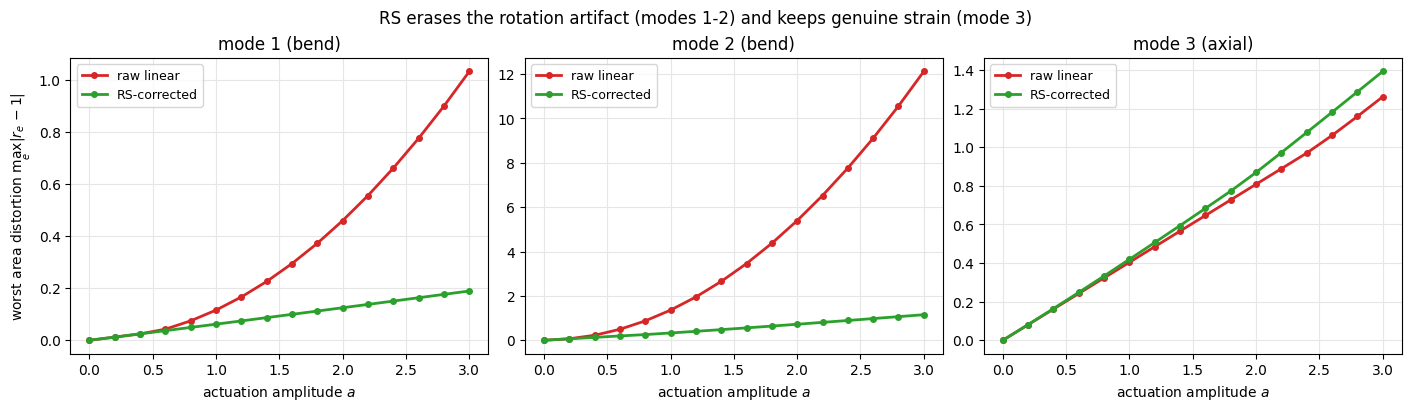

In [11]:
dist_lin = np.zeros((N_MODES, len(SWEEP_AMPS)))
dist_rs = np.zeros((N_MODES, len(SWEEP_AMPS)))
for i, m in enumerate(modes):
    pre_i = None
    for j, a in enumerate(SWEEP_AMPS):
        u_rs_a, pre_i = simkit.rotation_strain_coordinates(X, T, (a * m).reshape(-1), pinned=pin, pre=pre_i)
        dist_lin[i, j] = np.abs(np.linalg.det(simkit.deformation_gradient(X, T, X + a * m)) - 1.0).max()
        dist_rs[i, j] = np.abs(np.linalg.det(simkit.deformation_gradient(X, T, X + u_rs_a)) - 1.0).max()
    print(f"mode {i+1} at a={SWEEP_AMPS[-1]:.1f}: worst distortion raw {dist_lin[i, -1]:6.2f}, "
          f"RS {dist_rs[i, -1]:5.2f}")

fig, axes = plt.subplots(1, N_MODES, figsize=(14, 4.0), layout="constrained")
for i, ax in enumerate(axes):
    kind = "axial" if i == 2 else "bend"
    utils.line_plot(SWEEP_AMPS, {"raw linear": dist_lin[i], "RS-corrected": dist_rs[i]}, ax=ax,
                    colors={"raw linear": LIN_C, "RS-corrected": RS_C}, markers=True,
                    xlabel="actuation amplitude $a$", title=f"mode {i+1} ({kind})",
                    ylabel="worst area distortion $\\max_e|r_e-1|$" if i == 0 else "")
fig.suptitle("RS erases the rotation artifact (modes 1-2) and keeps genuine strain (mode 3)")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "distortion_vs_amp.png"),
                              copy_to=os.path.join(MEDIA_DIR, "018_distortion_vs_amp.png"))
plt.show()

### Takeaways

* A linear mode $x=X+a\,\phi$ moves vertices along straight lines. Rotation is nonlinear in position, so at
  large $a$ a bending mode inflates element area; in 2D the fake part is exactly $w^2$, from reading the
  turn to first order as $I+W$.
* RS coordinates split $\nabla u$ into a rotation generator $W$ and a strain $\mathrm{sym}(\nabla u)$,
  exponentiate $W$ into a true rotation $R$, keep $S=I+\mathrm{sym}(\nabla u)$, and fit one displacement
  whose Jacobian best matches $RS-I$ (a quadratic, pinned least-squares solve).
* The fix is selective: bending modes lose their spurious inflation and follow an arc, while an axial mode
  keeps its genuine strain.
* It gives rotation-aware motion at linear-mode cost for any cheap subspace that must rotate a lot. It is
  the skinning-eigenmodes lesson (tutorial 17) from the other side: there we *built* a rotation-capable
  basis, here we *repair* a rotation-blind one.